In [1]:
import numpy as np
from IPython.display import Image, display
from sedona.spark import SedonaContext
import itertools
import os
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd
from sedona.spark.stats.clustering.dbscan import dbscan
import math
import sedona.spark.stats.outlier_detection.local_outlier_factor as lof

In [2]:
%%capture
bucket_name = os.environ.get("SEDONA_SOURCE_BUCKET", "apache-sedona-book")

config = SedonaContext.builder()

sedona = SedonaContext.create(config.getOrCreate())

sedona.sparkContext.setLogLevel("ERROR")

sc = sedona.sparkContext

sedona.sparkContext.setCheckpointDir("checkpoint")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/23 22:53:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/11/23 22:53:23 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/11/23 22:53:25 WARN UDTRegistration: Cannot register UDT for org.geotools.coverage.grid.GridCoverage2D, which is already registered.
25/11/23 22:53:25 WARN SimpleFunctionRegistry: The function rs_union_aggr replaced a previously registered function.
25/11/23 22:53:25 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.geom.Geometry, which is already registered.
25/11/23 22:53:25 WARN UDTRegistration: Cannot register UDT for org.apache.sedona.common.S2Geography.Geography, which is already registered.
25/11/23 22:53:25 WARN UDTRegistration: Cannot register UDT for org.locationtech.jts.index.SpatialIndex, 

# loading denisty points

In [3]:
density_points = pd.read_csv("source_data/density_points/density_points.csv").reset_index()
density_points_sedona_df = sedona.createDataFrame(density_points).\
    selectExpr("index", "ST_Point(x, y) AS geom")

density_points_sedona_df.createOrReplaceTempView("density")

Text(0.5, 1.0, 'Point Locations')

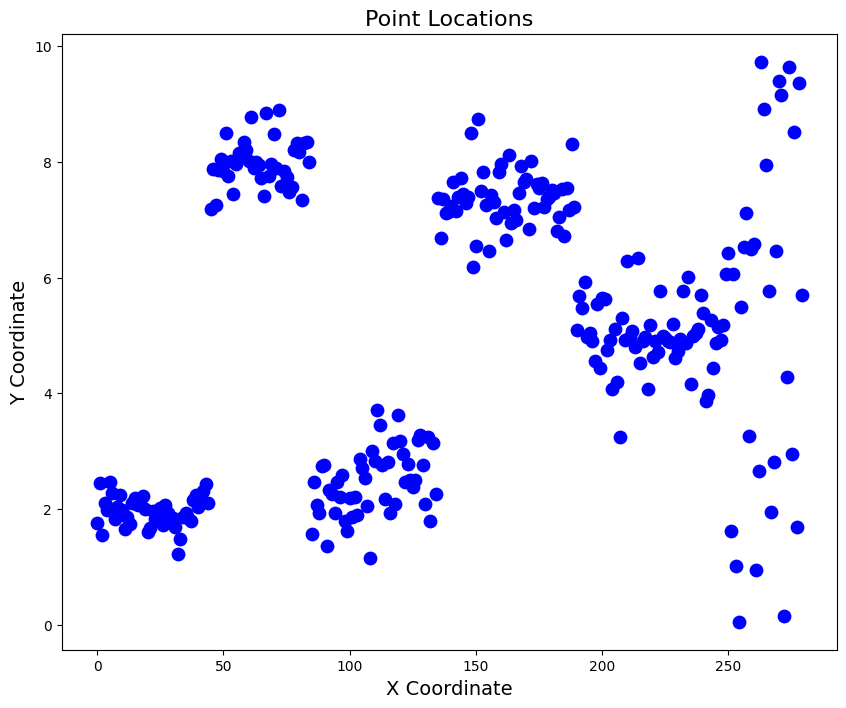

In [4]:
plt.figure(figsize=(10, 8))

plt.scatter(
    np.array(density_points)[:, 0], 
    np.array(density_points)[:, 1],
    s=80, 
    color="blue"
)
plt.xlabel('X Coordinate', fontsize=14)
plt.ylabel('Y Coordinate', fontsize=14)
plt.title('Point Locations', fontsize=16)

In [5]:
## note this example is not optimal, we use this as a explanation to understand the concept of the Local Outlier Detection algorithm

In [6]:
index = 100
k = 5

In [7]:
# find the nearest neigbors of the point
def get_neighbors(point_id, n):
    result = sedona.sql(
        f"""
        WITH selected_point AS (
            SELECT * 
            FROM density 
            WHERE index = {point_id}
        )
        SELECT 
            d.index,
            ST_Distance(s.geom, d.geom) AS distance,
            d.geom as geom,
            s.geom as point_geom
        FROM selected_point AS s, density AS d
        WHERE d.index <> {point_id}
        ORDER BY ST_Distance(s.geom, d.geom) ASC
        LIMIT {n}
        
        """
    )

    rows = [row for row in result.collect()]

    max_distance = max([row["distance"] for row in rows])

    return {
        "point_geom": rows[0]["point_geom"],
        "max_distance": max_distance,
        "index": point_id,
        "neighbors": [[row["index"], row["geom"]] for row in rows]
        
    }

In [8]:
point_index_neighbors = get_neighbors(index, k)

In [9]:
point_index_neighbors

{'point_geom': <POINT (2.192 5.656)>,
 'max_distance': 0.9960758908197521,
 'index': 100,
 'neighbors': [[277, <POINT (1.695 5.568)>],
  [118, <POINT (2.078 6.458)>],
  [126, <POINT (2.504 6.448)>],
  [123, <POINT (2.778 6.409)>],
  [99, <POINT (1.619 6.471)>]]}

In [10]:
## Vizualize the target point and its neighbors

In [11]:
neighbor_ids = [el[0] for el in point_index_neighbors['neighbors']]

viz_data = sedona.sql(
    f"""
    SELECT
        index,
        geom,
        'neighbor' AS type
    FROM density
    where index in {tuple(neighbor_ids)}
    UNION ALL
    SELECT
        index,
        geom,
        'point' AS type
    FROM density
    where index = {index}
    UNION ALL
    SELECT
        index,
        geom,
        'other' AS type
    FROM density
    where index <> {index} AND index not in {tuple(neighbor_ids)}
    """
)

In [12]:
gdf = gpd.GeoDataFrame(viz_data.toPandas(), geometry="geom")

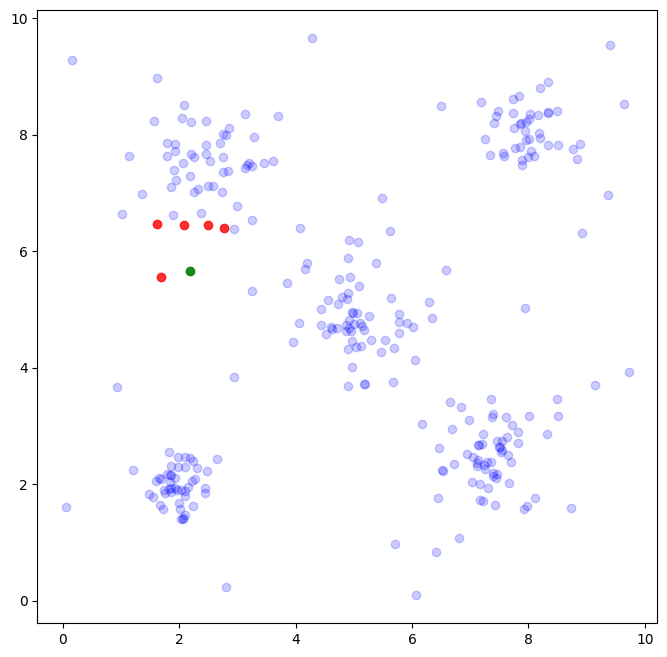

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

geom_types = {
    "neighbor": ["red", 0.8],
    "point": ["green", 0.9],
    "other": ["blue", 0.2],
}

for geom_type, properties in geom_types.items():
    gdf[gdf["type"] == geom_type].plot(alpha=properties[1], ax=ax, color=properties[0])

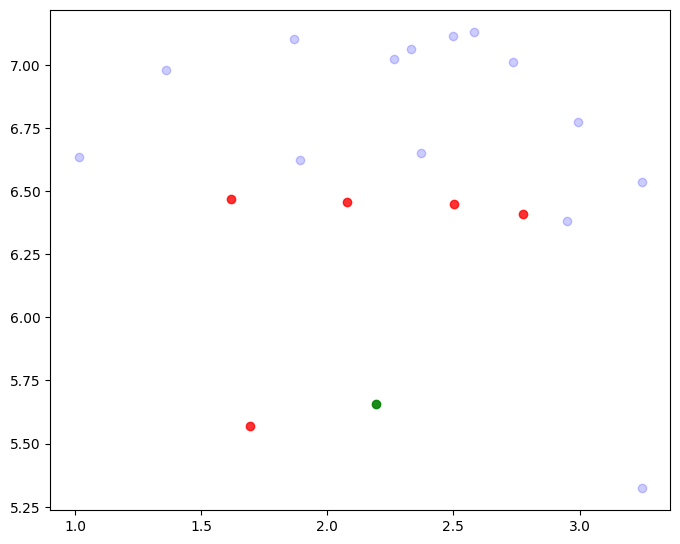

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

x, y = density_points[density_points["index"] == index][["x", "y"]].values.tolist()[0]

for geom_type, properties in geom_types.items():
    gdf[
        (gdf["type"] == geom_type) &
        (gdf["geom"].centroid.x < x+1.5) &
        (gdf["geom"].centroid.y < y+1.5) &
        (gdf["geom"].centroid.y > y-1.5) &
        (gdf["geom"].centroid.x > x-1.5)
    ].plot(alpha=properties[1], ax=ax, color=properties[0])

In [15]:
## Calculating the lrd

In [16]:
def get_lrd(index, k):
    neighbors = get_neighbors(index, k)
    rsum = 0
    n = 0
    for n_id, neighbor_geom in neighbors["neighbors"]:
        n += 1
        neighbor_k = get_neighbors(n_id, k)
        max_distance = neighbor_k['max_distance']
        max_distance_rounded = round(max_distance, 3)
        distance = neighbor_geom.distance(neighbors['point_geom'])
        distance_rounded = round(distance, 3)
        
        rd = max([distance, max_distance])
        rd_rounded = round(rd, 3)


        print(f"neighbor_id={n_id} max_distance={max_distance_rounded} distance={distance_rounded} rd={rd_rounded}")
        rsum += rd

    return 1/(1e-10 + (rsum/n))

In [17]:
point_lrd = get_lrd(index, k)

neighbor_id=277 max_distance=1.196 distance=0.504 rd=1.196


neighbor_id=118 max_distance=0.595 distance=0.81 rd=0.81


neighbor_id=126 max_distance=0.59 distance=0.852 rd=0.852


neighbor_id=123 max_distance=0.487 distance=0.954 rd=0.954


[Stage 10:================================================>    (110 + 11) / 121]

neighbor_id=99 max_distance=0.68 distance=0.996 rd=0.996


In [18]:
neighbord_lrds = []
for n in neighbor_ids:
    lrd = get_lrd(n, k)
    print(f"neighbor_id={n} lrd={round(lrd, 3)}")
    neighbord_lrds.append(lrd)

neighbor_id=100 max_distance=0.996 distance=0.504 rd=0.996


neighbor_id=99 max_distance=0.68 distance=0.906 rd=0.906


neighbor_id=118 max_distance=0.595 distance=0.969 rd=0.969


neighbor_id=103 max_distance=0.543 distance=1.075 rd=1.075


neighbor_id=126 max_distance=0.59 distance=1.196 rd=1.196
neighbor_id=277 lrd=0.972


...

neighbor_id=118 max_distance=0.595 distance=0.459 rd=0.595


neighbor_id=91 max_distance=0.64 distance=0.571 rd=0.64


neighbor_id=253 max_distance=1.006 distance=0.626 rd=1.006


[Stage 40:==============================================>      (106 + 11) / 121]

neighbor_id=101 max_distance=0.461 distance=0.68 rd=0.68
neighbor_id=99 lrd=1.444


In [19]:
neighbord_lrds

[0.9724928702498259,
 1.7355177879364991,
 1.7961271052207015,
 1.6678016660072947,
 1.4435008036708439]

In [20]:
sum(neighbord_lrds)/(len(neighbord_lrds) * point_lrd)

1.4643711653792912

## Whole dataset

In [27]:
from sedona.spark import dataframe_to_arrow
import geopandas as gpd

In [28]:
lof.local_outlier_factor(
    density_points_sedona_df,
    5
).\
    show(5, False)

+-----+---------------------------------------------+------------------+
|index|geom                                         |lof               |
+-----+---------------------------------------------+------------------+
|76   |POINT (7.480335462299658 8.404466746884305)  |1.0927074243981527|
|8    |POINT (2.0275282329606505 1.4037293256197323)|1.0191584064861596|
|41   |POINT (2.103085486870538 1.4710879533911798) |1.0371086942776708|
|224  |POINT (4.996987276805067 4.744590013830861)  |0.9561091949623256|
|19   |POINT (1.9959508325786195 1.68268672131323)  |1.2683124973214734|
+-----+---------------------------------------------+------------------+
only showing top 5 rows



In [29]:
lof.local_outlier_factor(
    density_points_sedona_df,
    5
).where("index = 100").show()

+-----+--------------------+------------------+
|index|                geom|               lof|
+-----+--------------------+------------------+
|  100|POINT (2.19153269...|1.4643711653792912|
+-----+--------------------+------------------+



<Axes: >

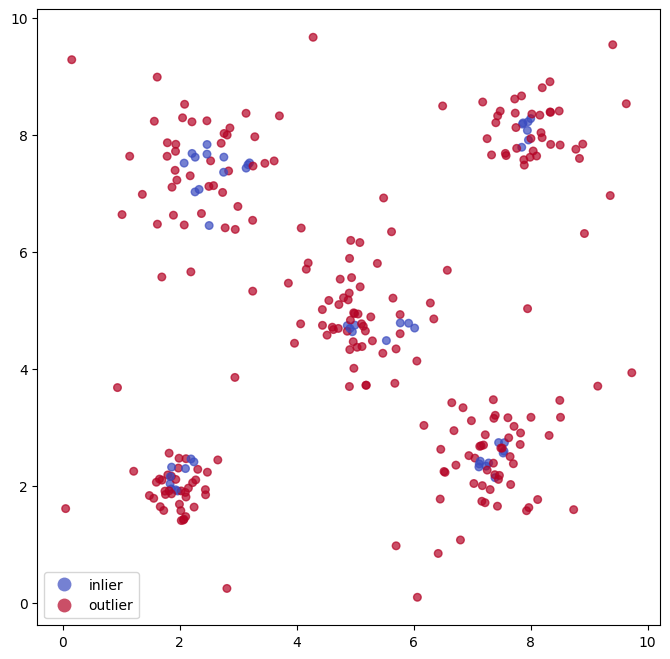

In [39]:
lof_df = lof.local_outlier_factor(
    density_points_sedona_df,
    5
)

lof_gdf = gpd.GeoDataFrame.from_arrow(dataframe_to_arrow(lof_df))
lof_gdf["type"] = lof_gdf["lof"].apply(lambda x: 'outlier' if x > 1 else 'inlier' if x < 1 else None)
lof_gdf.plot(column='type', cmap='coolwarm', figsize=(10,8), legend=True, marker='o', markersize=30, alpha=0.7)

<Axes: >

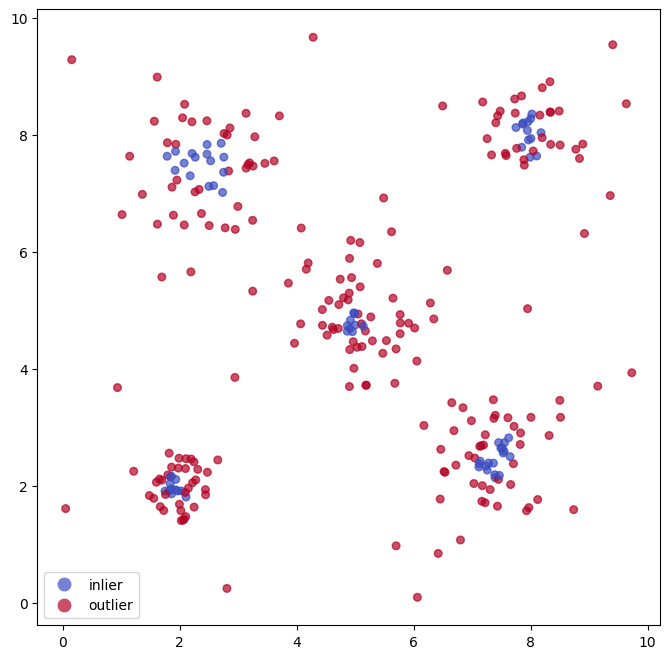

In [40]:
# increasing the number of neighbors to 10
lof_df = lof.local_outlier_factor(
    density_points_sedona_df,
    10
)

lof_gdf = gpd.GeoDataFrame.from_arrow(dataframe_to_arrow(lof_df))
lof_gdf["type"] = lof_gdf["lof"].apply(lambda x: 'outlier' if x > 1 else 'inlier' if x < 1 else None)
lof_gdf.plot(column='type', cmap='coolwarm', figsize=(10,8), legend=True, marker='o', markersize=30, alpha=0.7)

<Axes: >

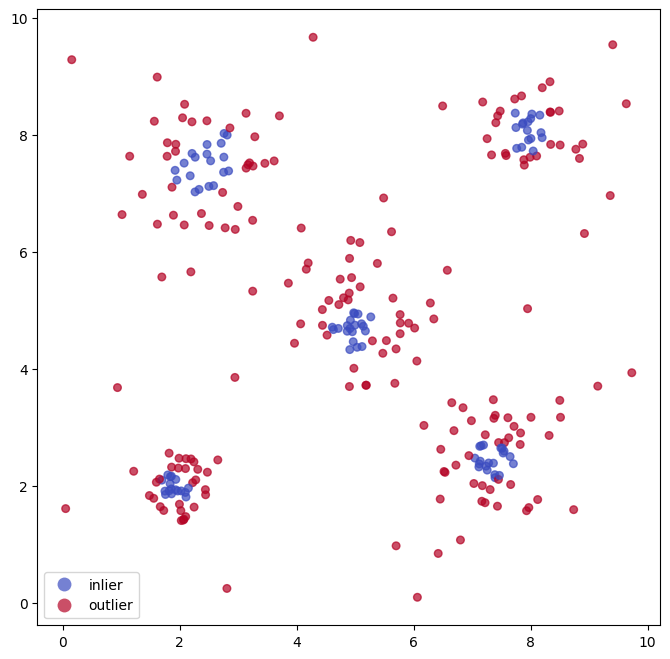

In [41]:
# increasing the number of neighbors to 20
lof_df = lof.local_outlier_factor(
    density_points_sedona_df,
    20
)

lof_gdf = gpd.GeoDataFrame.from_arrow(dataframe_to_arrow(lof_df))
lof_gdf["type"] = lof_gdf["lof"].apply(lambda x: 'outlier' if x > 1 else 'inlier' if x < 1 else None)
lof_gdf.plot(column='type', cmap='coolwarm', figsize=(10,8), legend=True, marker='o', markersize=30, alpha=0.7)

<Axes: >

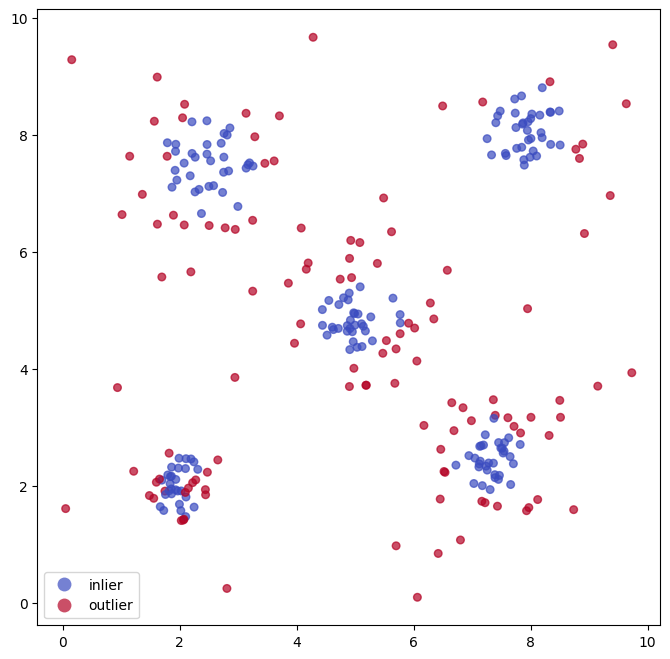

In [42]:
# increasing the number of neighbors to 40
lof_df = lof.local_outlier_factor(
    density_points_sedona_df,
    40
)

lof_gdf = gpd.GeoDataFrame.from_arrow(dataframe_to_arrow(lof_df))
lof_gdf["type"] = lof_gdf["lof"].apply(lambda x: 'outlier' if x > 1 else 'inlier' if x < 1 else None)
lof_gdf.plot(column='type', cmap='coolwarm', figsize=(10,8), legend=True, marker='o', markersize=30, alpha=0.7)